# 02 — Baseline-прогноз Prophet с учетом номерного фонда

## Цель ноутбука

Строим базовую модель Prophet, с которой дальше сравниваются улучшенные версии и XGBoost. Baseline нужен не как финальная модель, а как честная стартовая точка.

## Почему модель обучается на load_rate

В 2024 году изменился номерной фонд. Если обучать модель напрямую на абсолютном `y`, она может спутать изменение доступной емкости с изменением спроса. Поэтому при наличии `capacity_est` модель обучается на `load_rate = y / capacity_est`.

При этом все прогнозы и метрики переводятся обратно в активные бронирования, потому что бизнесу нужен ответ в понятных единицах: сколько бронирований ожидается в день.

## Что делает ноутбук

1. Загружает `df_daily.parquet`.
2. Загружает календарь праздников и школьных каникул.
3. Делит ряд на train и holdout.
4. Обучает baseline Prophet.
5. Считает MAE, RMSE, MAPE на holdout.
6. Сохраняет baseline-модель и прогноз.

## Выходы

- `baseline_metrics.json`
- `forecast_baseline.parquet`
- `prophet_baseline.joblib`

## 1. Импорты и настройки

In [1]:
import json
import sys
import warnings
from pathlib import Path
from prophet import Prophet
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

print(f'Python executable: {sys.executable}')

if Path('artifacts_forecasting').exists():
    OUT_DIR = Path('artifacts_forecasting')
    FORECASTING_DIR = Path.cwd()
elif Path('forecasting/artifacts_forecasting').exists():
    OUT_DIR = Path('forecasting') / 'artifacts_forecasting'
    FORECASTING_DIR = Path.cwd() / 'forecasting'
else:
    raise FileNotFoundError('artifacts_forecasting was not found. Run from ml/ or ml/forecasting/.')

if str(FORECASTING_DIR) not in sys.path:
    sys.path.insert(0, str(FORECASTING_DIR))

from holidays_ru import build_holidays_df

FORECAST_HORIZON = 365
HOLDOUT_DAYS = 90
CAPACITY_QUANTILE = 0.99


Python executable: C:\Users\sp1ts\anaconda3\python.exe


## 2. Загрузка временного ряда

In [2]:
df_daily = pd.read_parquet(OUT_DIR / 'df_daily.parquet')
df_daily['ds'] = pd.to_datetime(df_daily['ds'])
df_daily = df_daily.sort_values('ds').reset_index(drop=True)

TARGET_COL = 'load_rate' if {'load_rate', 'capacity_est'}.issubset(df_daily.columns) else 'y'

print(f'Days: {len(df_daily):,}')
print(f'Date range: {df_daily["ds"].min().date()} - {df_daily["ds"].max().date()}')
print(f'Model target: {TARGET_COL}')
print(f'Mean active bookings: {df_daily["y"].mean():.1f}')
if TARGET_COL == 'load_rate':
    display(df_daily.groupby('year').agg(max_y=('y', 'max'), capacity_est=('capacity_est', 'first'), mean_load_rate=('load_rate', 'mean')).round(3))
display(df_daily.head())


Days: 1,399
Date range: 2022-01-01 - 2025-10-30
Model target: load_rate
Mean active bookings: 438.4


,max_y,capacity_est,mean_load_rate
year,,,
2022,980,961.0,0.392
2023,992,982.0,0.532
2024,861,824.0,0.509
2025,813,779.0,0.559


,ds,y,month,year,weekday,day_of_week,week,is_weekend,season,is_holiday,is_day_off,capacity_est,load_rate
0,2022-01-01,126,1,2022,5,5,52,1,winter,1,1,961.0,0.131113
1,2022-01-02,355,1,2022,6,6,52,1,winter,1,1,961.0,0.369407
2,2022-01-03,639,1,2022,0,0,1,0,winter,1,1,961.0,0.664932
3,2022-01-04,672,1,2022,1,1,1,0,winter,1,1,961.0,0.699272
4,2022-01-05,613,1,2022,2,2,1,0,winter,1,1,961.0,0.637877


## 2.1. Что берем из EDA

EDA из `01_timeseries_build.ipynb` задает логику baseline-модели:

- сильная годовая сезонность: лето заметно выше зимы, поэтому включаем `yearly_seasonality`;
- емкость менялась по годам, поэтому при наличии `capacity_est` моделируем `load_rate`, а затем переводим прогноз обратно в активные бронирования;
- недельный эффект слабее годового, но регулярный, поэтому оставляем `weekly_seasonality`;
- праздники и школьные каникулы используем как дополнительный календарный сигнал, а не как основной драйвер ряда.


## 3. Календарь праздников

In [3]:
holidays = build_holidays_df(include_official=True, include_school=True)
print(f'Holiday rows: {len(holidays):,}')
print(f'Unique holiday labels: {holidays["holiday"].nunique():,}')
display(holidays.head())


Holiday rows: 974
Unique holiday labels: 12


,holiday,ds,lower_window,upper_window
0,new_year,2017-01-01,-1,1
1,new_year,2017-01-02,-1,1
2,new_year,2017-01-03,-1,1
3,new_year,2017-01-04,-1,1
4,new_year,2017-01-05,-1,1


## 4. Разделение на train / holdout

In [4]:
last_real_date = df_daily['ds'].max()
cutoff_date = last_real_date - pd.Timedelta(days=HOLDOUT_DAYS)

df_train = df_daily[df_daily['ds'] <= cutoff_date].copy()
df_test = df_daily[df_daily['ds'] > cutoff_date].copy()

train_prophet = df_train[['ds', TARGET_COL]].rename(columns={TARGET_COL: 'y'})

print(f'Train:   {df_train["ds"].min().date()} - {df_train["ds"].max().date()} ({len(df_train):,} days)')
print(f'Holdout: {df_test["ds"].min().date()} - {df_test["ds"].max().date()} ({len(df_test):,} days)')


Train:   2022-01-01 - 2025-08-01 (1,309 days)
Holdout: 2025-08-02 - 2025-10-30 (90 days)


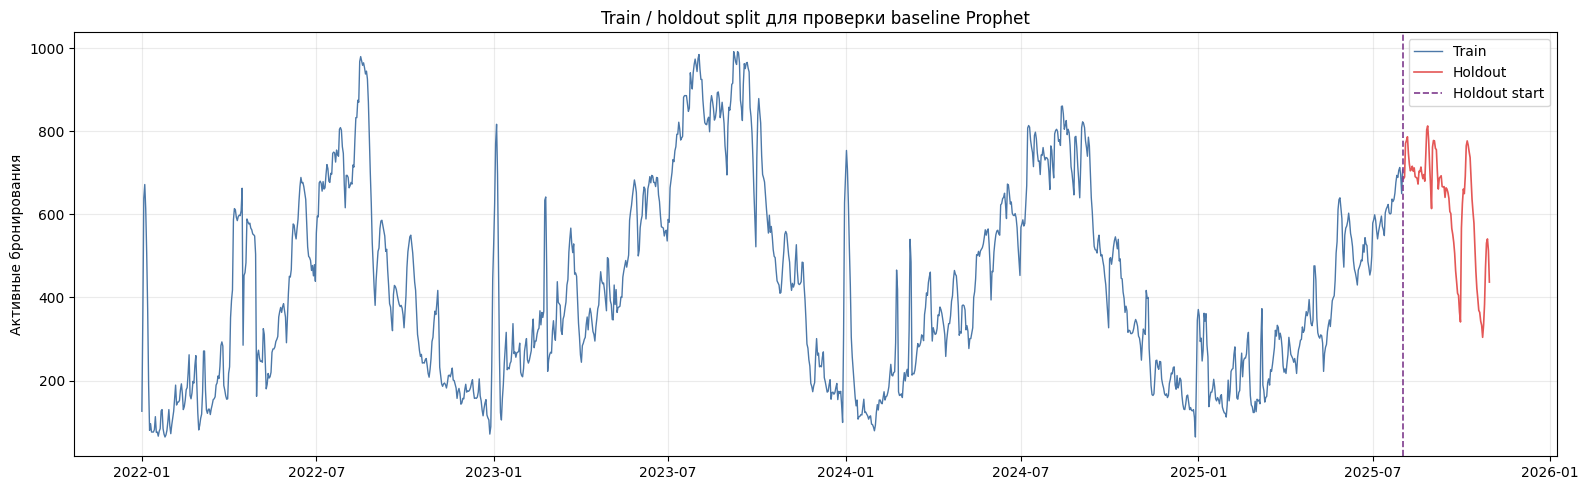

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_train['ds'], df_train['y'], color='#4C78A8', linewidth=1.0, label='Train')
ax.plot(df_test['ds'], df_test['y'], color='#E45756', linewidth=1.2, label='Holdout')
ax.axvline(cutoff_date, color='#7F3C8D', linestyle='--', linewidth=1.2, label='Holdout start')
ax.set_title('Train / holdout split для проверки baseline Prophet')
ax.set_ylabel('Активные бронирования')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'prophet_baseline_train_holdout.png', dpi=160, bbox_inches='tight')
plt.show()


## 5. Обучение baseline Prophet

In [6]:
def build_baseline_model() -> Prophet:
    return Prophet(
        holidays=holidays,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        stan_backend='CMDSTANPY',
        seasonality_mode='additive',
        interval_width=0.90,
        uncertainty_samples=500,
    )

model_baseline = build_baseline_model()
model_baseline.fit(train_prophet)
print('Baseline Prophet fitted.')


20:06:38 - cmdstanpy - INFO - Chain [1] start processing
20:06:39 - cmdstanpy - INFO - Chain [1] done processing


Baseline Prophet fitted.


Baseline Prophet fitted.


## 6. Прогноз и перевод обратно в активные бронирования

In [7]:
def capacity_for_dates(ds: pd.Series) -> pd.Series:
    if TARGET_COL != 'load_rate':
        return pd.Series(np.nan, index=ds.index)
    capacity_by_year = df_daily.groupby('year')['capacity_est'].first().to_dict()
    last_capacity = float(df_daily.sort_values('ds')['capacity_est'].iloc[-1])
    return ds.dt.year.map(capacity_by_year).fillna(last_capacity).astype(float)

def convert_forecast_to_bookings(forecast: pd.DataFrame) -> pd.DataFrame:
    result = forecast.copy()
    if TARGET_COL == 'load_rate':
        result['capacity_est'] = capacity_for_dates(result['ds'])
        result['yhat_rate'] = result['yhat']
        result['yhat_lower_rate'] = result['yhat_lower']
        result['yhat_upper_rate'] = result['yhat_upper']
        result['yhat'] = (result['yhat_rate'] * result['capacity_est']).clip(lower=0)
        result['yhat_lower'] = (result['yhat_lower_rate'] * result['capacity_est']).clip(lower=0)
        result['yhat_upper'] = (result['yhat_upper_rate'] * result['capacity_est']).clip(lower=0)
    return result

future_holdout = model_baseline.make_future_dataframe(periods=HOLDOUT_DAYS, freq='D', include_history=False)
forecast_holdout_raw = model_baseline.predict(future_holdout)
forecast_holdout = convert_forecast_to_bookings(forecast_holdout_raw)

future_full = model_baseline.make_future_dataframe(periods=FORECAST_HORIZON, freq='D', include_history=True)
forecast_baseline = convert_forecast_to_bookings(model_baseline.predict(future_full))

print(f'Forecast rows: {len(forecast_baseline):,}')
display(forecast_baseline[['ds', 'yhat', 'yhat_lower', 'yhat_upper'] + (['capacity_est', 'yhat_rate'] if TARGET_COL == 'load_rate' else [])].tail())


Forecast rows: 1,674


,ds,yhat,yhat_lower,yhat_upper,capacity_est,yhat_rate
1669,2026-07-28,758.510248,642.270624,878.739186,779.0,0.973697
1670,2026-07-29,757.113544,638.140714,886.225543,779.0,0.971904
1671,2026-07-30,753.361067,623.083870,878.588704,779.0,0.967087
1672,2026-07-31,758.340795,630.698397,874.810874,779.0,0.973480
1673,2026-08-01,757.701431,636.521682,880.990853,779.0,0.972659


## 7. Метрики на holdout

In [8]:
def mape_pct(y_true: pd.Series, y_pred: pd.Series) -> float:
    mask = y_true != 0
    return float(((y_true[mask] - y_pred[mask]).abs() / y_true[mask]).mean() * 100)

eval_df = df_test.merge(forecast_holdout[['ds', 'yhat'] + (['yhat_rate'] if TARGET_COL == 'load_rate' else [])], on='ds', how='inner')

baseline_metrics = {
    'model': 'prophet_capacity_adjusted' if TARGET_COL == 'load_rate' else 'prophet_baseline',
    'target': TARGET_COL,
    'capacity_quantile': CAPACITY_QUANTILE if TARGET_COL == 'load_rate' else None,
    'cutoff_date': cutoff_date.date().isoformat(),
    'mae': round(float(mean_absolute_error(eval_df['y'], eval_df['yhat'])), 2),
    'rmse': round(float(mean_squared_error(eval_df['y'], eval_df['yhat']) ** 0.5), 2),
    'mape_pct': round(mape_pct(eval_df['y'], eval_df['yhat']), 2),
}
if TARGET_COL == 'load_rate':
    baseline_metrics['mae_rate'] = round(float(mean_absolute_error(eval_df['load_rate'], eval_df['yhat_rate'])), 4)
    baseline_metrics['rmse_rate'] = round(float(mean_squared_error(eval_df['load_rate'], eval_df['yhat_rate']) ** 0.5), 4)

print(json.dumps(baseline_metrics, ensure_ascii=False, indent=2))


{
  "model": "prophet_capacity_adjusted",
  "target": "load_rate",
  "capacity_quantile": 0.99,
  "cutoff_date": "2025-08-01",
  "mae": 120.1,
  "rmse": 151.96,
  "mape_pct": 19.68,
  "mae_rate": 0.1542,
  "rmse_rate": 0.1951
}


## 8. Визуализация

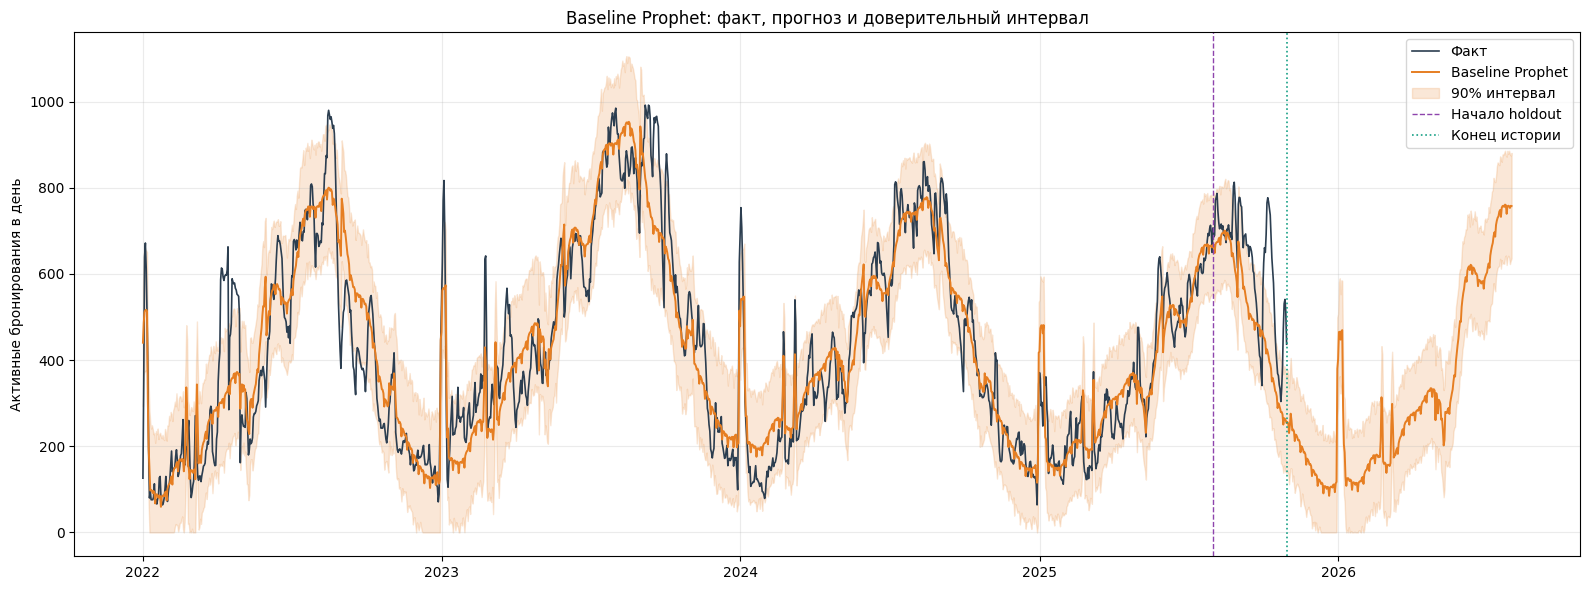

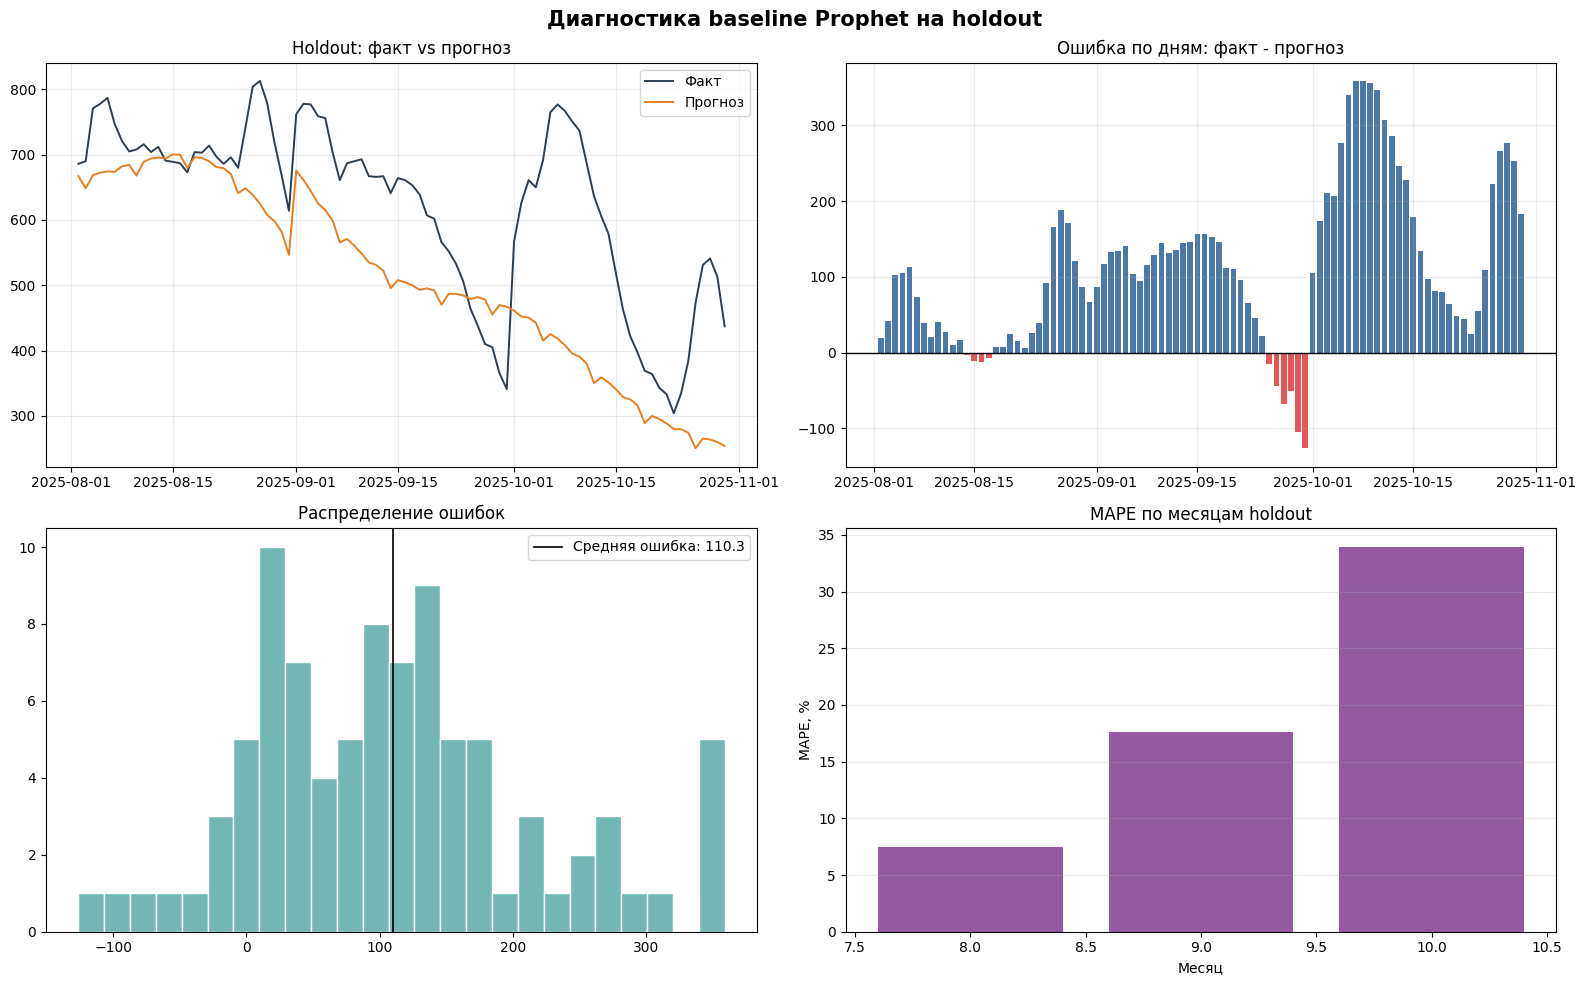

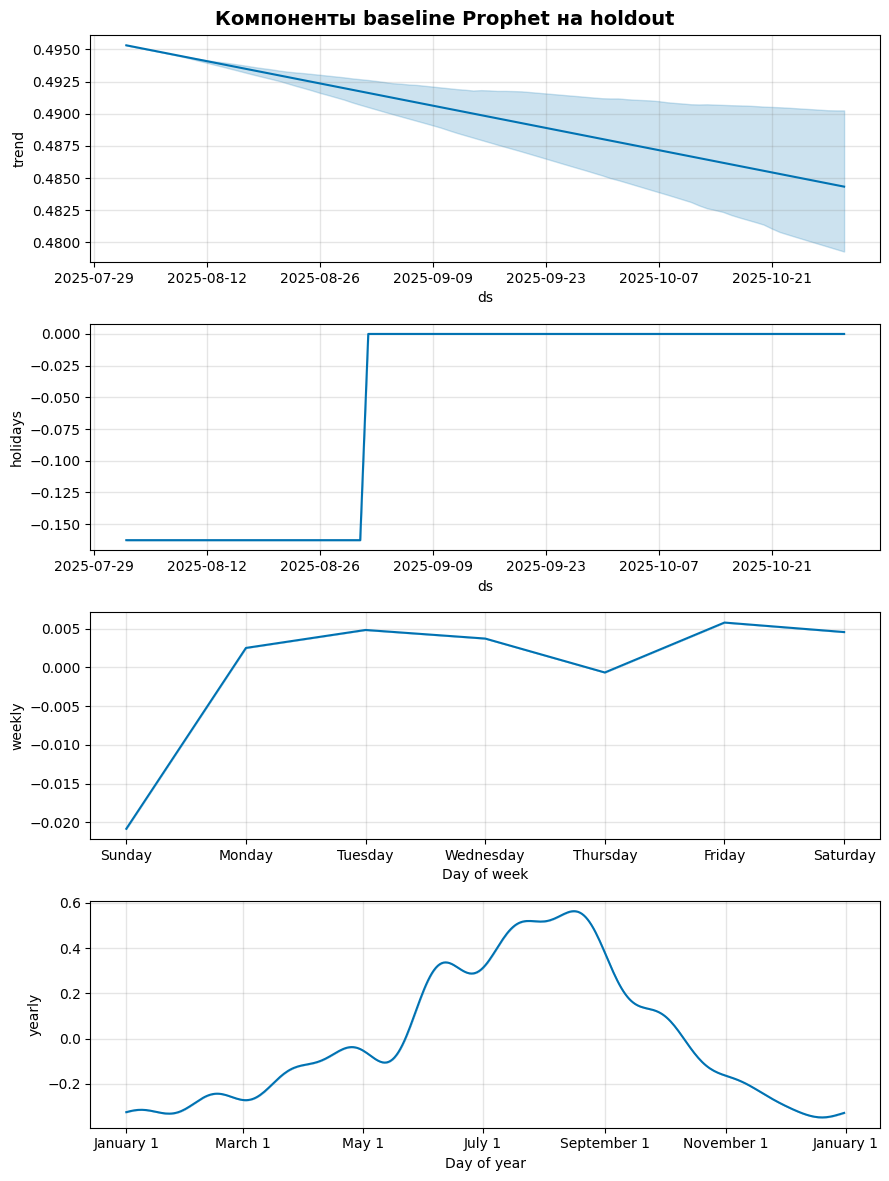

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_daily['ds'], df_daily['y'], label='Факт', color='#2c3e50', linewidth=1.2)
ax.plot(forecast_baseline['ds'], forecast_baseline['yhat'], label='Baseline Prophet', color='#e67e22', linewidth=1.4)
ax.fill_between(forecast_baseline['ds'], forecast_baseline['yhat_lower'], forecast_baseline['yhat_upper'], color='#e67e22', alpha=0.18, label='90% интервал')
ax.axvline(cutoff_date, color='#8e44ad', linestyle='--', linewidth=1, label='Начало holdout')
ax.axvline(last_real_date, color='#16a085', linestyle=':', linewidth=1.2, label='Конец истории')
ax.set_title('Baseline Prophet: факт, прогноз и доверительный интервал')
ax.set_ylabel('Активные бронирования в день')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'prophet_baseline_forecast.png', dpi=160, bbox_inches='tight')
plt.show()

eval_plot = eval_df.copy()
eval_plot['error'] = eval_plot['y'] - eval_plot['yhat']
eval_plot['abs_pct_error'] = (eval_plot['error'].abs() / eval_plot['y'].replace(0, np.nan)) * 100
eval_plot['month'] = eval_plot['ds'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Диагностика baseline Prophet на holdout', fontsize=15, fontweight='bold')
axes[0, 0].plot(eval_plot['ds'], eval_plot['y'], color='#2c3e50', linewidth=1.4, label='Факт')
axes[0, 0].plot(eval_plot['ds'], eval_plot['yhat'], color='#e67e22', linewidth=1.4, label='Прогноз')
axes[0, 0].set_title('Holdout: факт vs прогноз')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.25)

axes[0, 1].bar(eval_plot['ds'], eval_plot['error'], color=np.where(eval_plot['error'] >= 0, '#4C78A8', '#E45756'))
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Ошибка по дням: факт - прогноз')
axes[0, 1].grid(True, alpha=0.25)

axes[1, 0].hist(eval_plot['error'], bins=25, color='#72B7B2', edgecolor='white')
axes[1, 0].axvline(eval_plot['error'].mean(), color='black', linewidth=1.2, label=f'Средняя ошибка: {eval_plot["error"].mean():.1f}')
axes[1, 0].set_title('Распределение ошибок')
axes[1, 0].legend()

monthly_error = eval_plot.groupby('month')['abs_pct_error'].mean()
axes[1, 1].bar(monthly_error.index, monthly_error.values, color='#7F3C8D', alpha=0.85)
axes[1, 1].set_title('MAPE по месяцам holdout')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('MAPE, %')
axes[1, 1].grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'prophet_baseline_holdout_diagnostics.png', dpi=160, bbox_inches='tight')
plt.show()

components_fig = model_baseline.plot_components(forecast_holdout_raw)
components_fig.suptitle('Компоненты baseline Prophet на holdout', fontsize=14, fontweight='bold')
components_fig.tight_layout()
components_fig.savefig(OUT_DIR / 'prophet_baseline_components_holdout.png', dpi=160, bbox_inches='tight')
plt.show()


## 9. Сохранение baseline-артефактов

In [10]:
model_baseline_final = build_baseline_model()
model_baseline_final.fit(df_daily[['ds', TARGET_COL]].rename(columns={TARGET_COL: 'y'}))
future_final = model_baseline_final.make_future_dataframe(periods=FORECAST_HORIZON, freq='D', include_history=True)
forecast_baseline = convert_forecast_to_bookings(model_baseline_final.predict(future_final))

with open(OUT_DIR / 'baseline_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_metrics, f, ensure_ascii=False, indent=2)
joblib.dump(model_baseline_final, OUT_DIR / 'prophet_baseline.joblib')
forecast_baseline.to_parquet(OUT_DIR / 'forecast_baseline.parquet', index=False)

print(f'Saved: {OUT_DIR / "baseline_metrics.json"}')
print(f'Saved: {OUT_DIR / "prophet_baseline.joblib"}')
print(f'Saved: {OUT_DIR / "forecast_baseline.parquet"}')


20:06:41 - cmdstanpy - INFO - Chain [1] start processing
20:06:41 - cmdstanpy - INFO - Chain [1] done processing


Saved: artifacts_forecasting\baseline_metrics.json
Saved: artifacts_forecasting\prophet_baseline.joblib
Saved: artifacts_forecasting\forecast_baseline.parquet


Saved: artifacts_forecasting\baseline_metrics.json
Saved: artifacts_forecasting\prophet_baseline.joblib
Saved: artifacts_forecasting\forecast_baseline.parquet
